# Introduction

The dataset is used for this competition is synthetic, but based on a real dataset and generated using a CTGAN. The original dataset deals with predicting identifying spam emails via various extracted features from the email. Although the features are anonymized, they have properties relating to real-world features.

Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target.



# First thoughts
* This months Tabular Playground Dataset is once again quite large, so managing both cpu usage and ram is going to be an important element of the project.
* It looks like another classification problem.
* There is no missing data, so imputing values will not be required.
* Looks like there is no categorical features
* Data engineering and feature importance may be important.
* Its likely that model selection and hyper parameter tuning will be important.
* Staking, blending and ensambles are likely to be important to get higher scores.

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing data

In [2]:
train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv')
test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv')
sample_submission = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

#### Describing the data

In [3]:
train.describe().style.background_gradient("copper_r")

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,0.306508,2.497590,306.644536,2.647901,0.177850,2.556832,2.699650,2.571593,2.538273,0.134370,2.579987,2.759273,0.128958,2.477244,2.662859,2.631040,0.362479,2.483075,2.471319,0.108097,0.093783,0.062157,2.559781,0.097061,0.141055,2.580093,2.459101,0.057945,0.216789,2.471344,0.125638,0.107798,0.170434,0.054776,2.463409,55.698848,1.769510,2.595079,2.410926,0.593497,2.646091,2.582621,0.108999,2.500058,3.227368,2.595892,0.061749,2.537154,0.084997,0.244993,2.558957,0.093148,0.314877,0.109274,2.455216,2.571747,0.270019,2.604276,0.099612,0.087340,0.088858,0.144262,0.124303,0.340198,0.086385,2.513444,2.577005,2.522315,0.134467,0.189364,2.494925,2.632673,0.129834,0.050814,2.551266,0.174057,0.231822,2.420256,0.101771,0.349875,2.550175,0.902983,2.598029,0.162773,0.501982,2.587270,2.653461,0.265197,0.335756,0.056866,0.071252,2.444471,0.155260,0.059407,0.144932,0.106419,2.547853,2.590159,0.158881,0.123048,0.506010
std,173205.225094,0.522450,1.554018,551.743893,1.544529,0.417488,1.562527,1.564000,1.549361,1.532988,0.421892,1.604389,1.545217,0.210861,1.517694,1.481966,1.531067,1.346352,1.577456,1.541571,0.395313,0.308938,0.054796,1.556496,0.333590,0.342377,1.609573,1.567891,0.114129,0.339320,1.524330,0.296563,0.412291,0.440615,0.109661,1.566572,130.132892,1.785712,1.562506,1.572078,0.951892,1.567926,1.537063,0.356046,1.575150,5.414258,1.559765,0.365426,1.502016,0.292977,0.622615,1.611025,0.341598,0.579662,0.201639,1.533550,1.485223,0.852348,1.532116,0.590106,0.432437,0.151993,0.377962,0.414040,0.623011,0.216007,1.516342,1.563820,1.532317,0.398998,0.744550,1.575232,1.541872,0.308313,0.049142,1.513612,0.641809,1.206276,1.557891,0.245734,0.596830,1.576794,1.335611,1.542775,0.295831,2.364291,1.564173,1.546943,0.562230,0.993598,0.128607,0.112654,1.542509,0.548397,0.119426,0.462015,0.209128,1.558427,1.525091,0.436190,0.264896,0.499964
min,0.000000,-3.797450,-1.223960,-1842.530000,-1.368560,-3.206210,-1.169770,-1.059310,-1.281970,-1.242020,-2.577840,-1.309730,-1.451570,-0.678145,-1.295160,-1.213890,-1.450540,-18.169600,-1.387720,-1.221020,-5.334110,-2.858550,-0.151519,-1.201070,-2.721660,-2.645250,-1.380430,-1.147260,-2.281050,-4.596

#### Droping id column

In [4]:
train.drop('id', axis=1, inplace=True)
test.drop('id', axis=1, inplace=True)

# Features

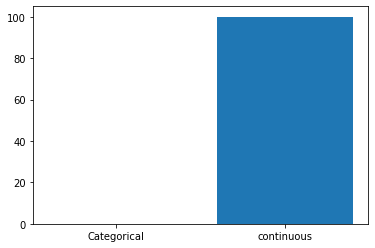

In [5]:
features=[]
cat_features=[]
cont_features=[]

for feature in test.columns:
    features.append(feature)
    if test.dtypes[feature] == object or train.dtypes[feature] == 'int8':
        cat_features.append(feature)
    else:
        cont_features.append(feature)

plt.bar([1,2],[len(cat_features),len(cont_features)])
plt.xticks([1,2],('Categorical','continuous'))
plt.show()

The above plot clearly tells that all features are continuous and thus no categorical features this time.

# Info about data

#### Train and test shape

In [6]:
print("Shape of Train data:", train.shape)
print("Shape of Test data:", test.shape)

Shape of Train data: (600000, 101)
Shape of Test data: (540000, 100)


#### Missing data

In [7]:
print("Missing train data:", train.isnull().sum().sum(), f"({train.isnull().sum().sum()/train.shape[0]}%)")
print("Missing test data:", test.isnull().sum().sum(), f"({test.isnull().sum().sum()/test.shape[0]}%)")

Missing train data: 0 (0.0%)
Missing test data: 0 (0.0%)


#### Feature type

In [8]:
print("Categorical features:", len(cat_features))
print("Continuous features:", len(cont_features))

Categorical features: 0
Continuous features: 100


#### Memory used

In [9]:
print("Memory used by train data:", train.memory_usage().sum() / 1024**2)
print("Memory used by test data:", test.memory_usage().sum() / 1024**2)

Memory used by train data: 462.3414306640625
Memory used by test data: 411.9874267578125


# Glance at train data

In [10]:
pd.set_option("display.max_columns", None)

In [11]:
train.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,0.012330,1.607190,-0.318058,0.560137,2.806880,1.35114,2.535930,0.197527,0.676494,1.98979,-3.842450,0.037380,0.230322,3.33055,0.009397,0.144738,3.05131,1.30362,0.033225,-0.018284,2.748210,-0.009294,-0.036271,-0.049871,0.019484,3.898460,11.2863,1.138020,3.366880,4.94446,-0.105772,2.11345,3.452230,0.789430,1.113210,1.49157,2.440370,0.041824,3.35537,0.053691,1.701270,0.908831,0.094902,0.030219,0.597024,4.443410,1.586490,-0.068686,-0.108268,0.061044,0.046099,0.017113,-0.027551,0.019483,-0.048826,0.050748,3.729300,5.017440,4.186880,0.063342,0.121043,1.37175,4.017450,0.167613,0.039753,2.042360,-0.016614,0.107679,3.507250,0.013660,-0.097023,5.396070,0.244457,3.49184,0.113090,-0.015472,4.208790,4.106560,0.037227,-0.118814,0.067086,0.010739,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,0.037706,0.331749,0.325091,0.062040,2.262150,4.33943,-0.224999,0.233586,3.381280,1.90299,0.067874,-0.051268,0.006135,2.60444,0.103441,0.067638,4.75362,1.85552,-0.181834,0.008359,3.166340,0.011850,0.022292,0.069320,0.117109,0.315276,24.4807,1.672270,-0.409067,4.95475,0.092358,2.60318,1.954690,0.005896,3.289340,2.56453,0.817706,0.025997,4.61749,1.575540,0.066105,0.681634,0.025247,0.183500,0.110038,2.746120,0.835586,0.188196,4.960640,0.136087,-0.008493,-0.015264,-0.010841,0.064584,0.102548,0.093611,0.964089,0.630422,4.307340,0.091289,-0.036360,3.61767,3.103240,0.000657,0.051302,1.924620,0.123294,-0.022671,1.548120,-0.010397,0.058330,3.661310,-0.118386,2.35739,-0.009112,0.178701,4.097350,3.532890,0.005244,0.121381,0.109968,0.135838,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,0.056995,0.328684,2.968810,0.105244,2.069490,5.30986,1.354790,-0.262018,1.379080,1.48091,0.020542,-0.008806,0.109348,1.68365,0.038180,0.123716,1.11248,3.57166,0.120601,0.082069,2.233520,0.002270,0.045182,0.014405,0.011599,-0.502849,33.7382,1.417500,1.071350,3.22296,2.122030,3.08216,0.637555,-0.006822,-0.390943,17.34570,3.700430,-0.033600,1.57824,0.051978,-0.002004,2.690960,0.018367,-0.030468,0.111409,2.187470,-0.325000,-0.019944,3.455030,0.068105,-0.009812,-0.010627,0.027571,-0.007121,-0.048914,-0.002574,1.865090,2.404170,0.411741,0.057749,0.525174,2.16879,0.828297,0.089848,0.093744,4.949010,-0.010978,0.076671,0.266784,0.038691,0.382731,3.847600,-0.121482,3.74084,0.147098,-0.016566,0.614651,2.125840,0.078828,0.979808,0.026758,0.117310,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,0.123494,1.002680,4.869600,0.058411,2.497850,1.23843,2.348360,0.175475,1.608890,2.02881,0.042086,0.005141,0.076506,1.65122,0.111813,0.121641,0.58912,4.23692,-0.032843,0.058168,0.712927,0.097465,0.072744,0.000324,0.063362,4.063820,25.3824,0.576572,2.026210,2.96843,1.085670,1.71088,1.371820,0.034631,0.722607,71.44850,3.034580,0.092245,3.45310,0.044829,0.027195,4.082850,0.046955,0.063695,0.029225,0.672022,0.185311,0.164284,3.804560,0.062306,-0.021406,0.009471,0.110884,0.026837,2.931160,0.068112,-0.495192,1.345280,2.242750,0.035611,-0.139274,4.74243,3.292740,0.117877,0.065605,0.556711,-0.058029,0.070501,1.101250,0.068559,0.162928,4.070180,-0.008835,3.89678,0.913739,-0.163204,3.074850,4.356780,-0.048894,4.917990,0.069930,-0.015347,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,

# Target distribution

<AxesSubplot:title={'center':'Target distibution'}, ylabel='None'>

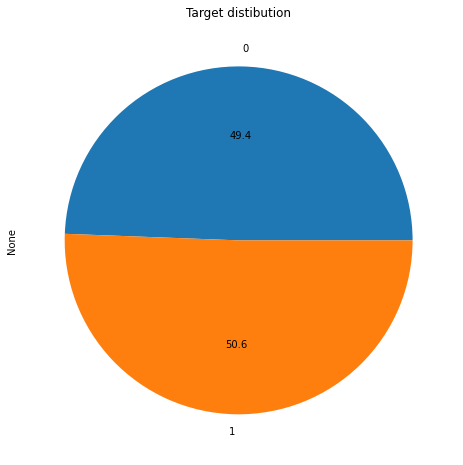

In [12]:
pie, ax = plt.subplots(figsize=[18,8])
train.groupby('target').size().plot(kind='pie',autopct='%.1f',ax=ax,title='Target distibution')

#### All credits: https://www.kaggle.com/davidcoxon/first-look-at-october-data
# Distribution of data

Train: Red
Test: Green


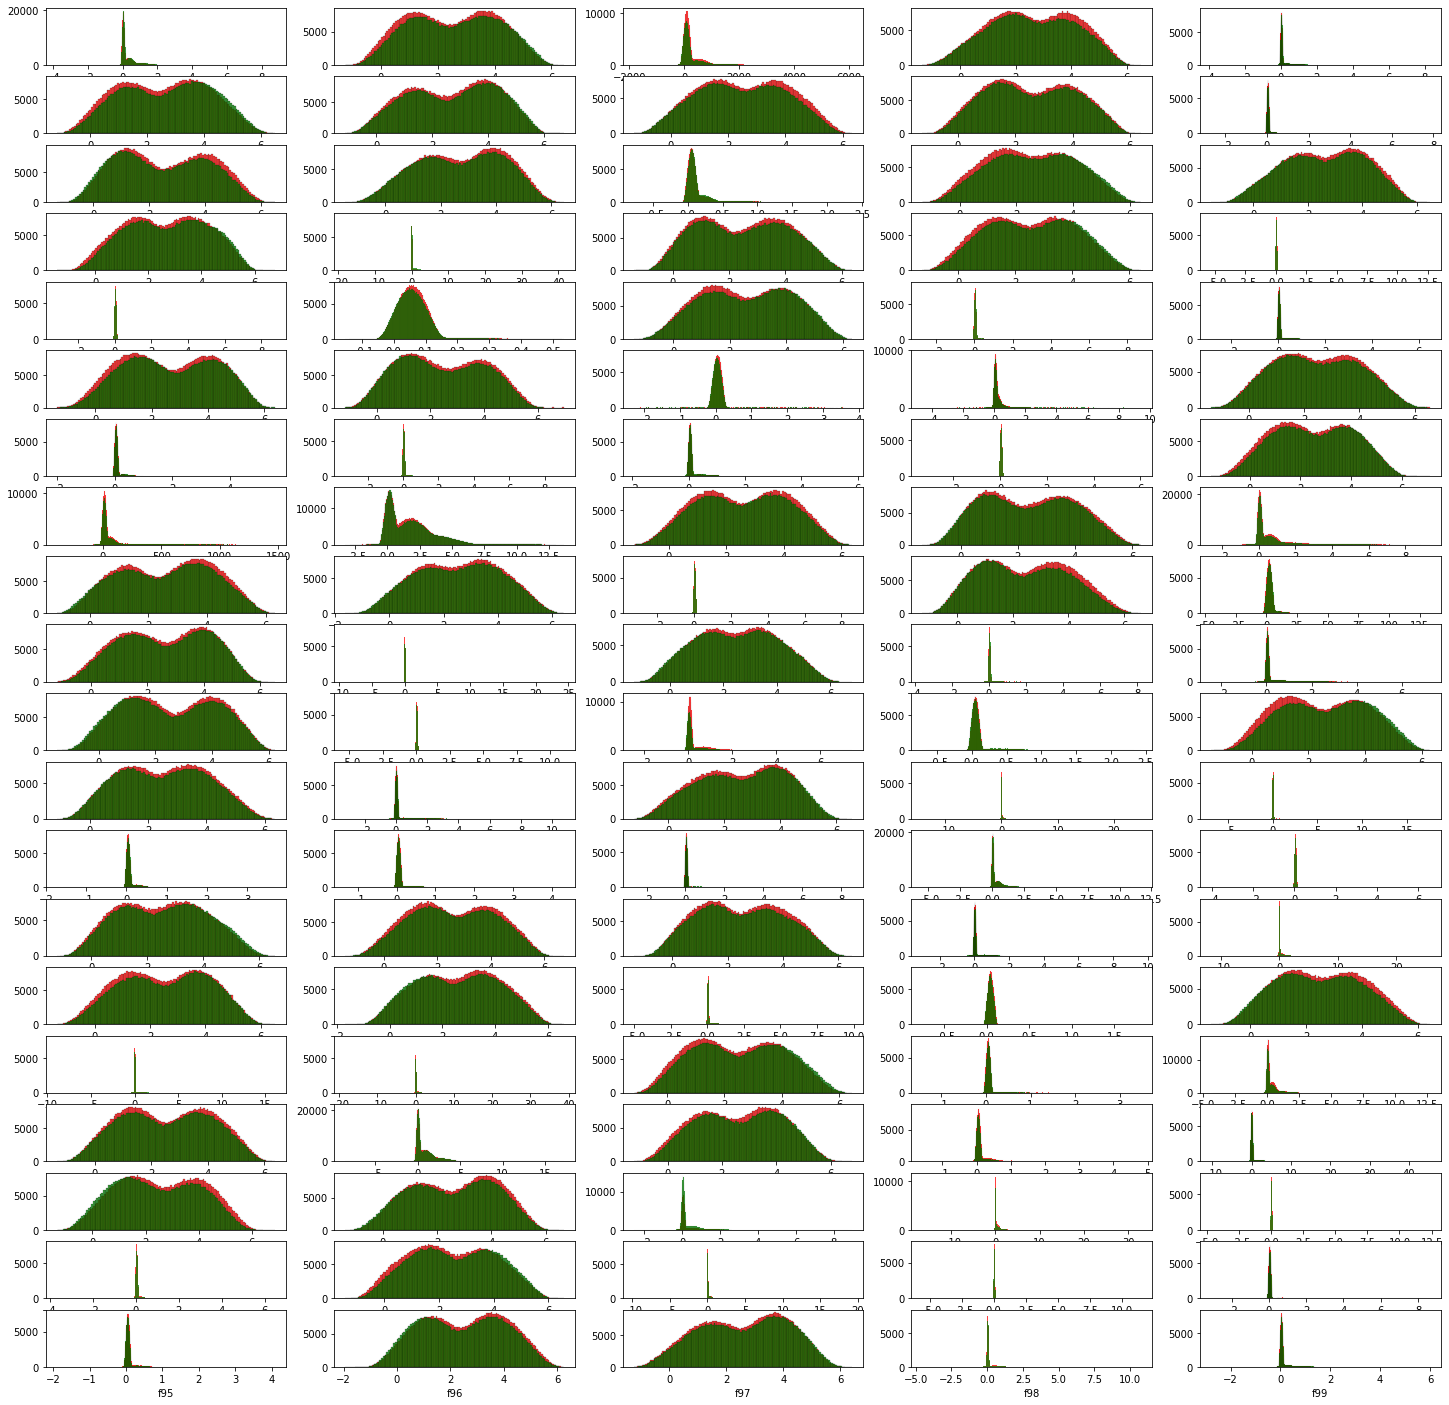

In [13]:
print("Train: Red")
print("Test: Green")
nrows = 20
ncols = 5
i = 0

fig, ax = plt.subplots(nrows, ncols, figsize = (25, 25))

for row in range(nrows):
    for col in range(ncols):
        sns.histplot(data = train.iloc[:, i],color='r', ax = ax[row, col]).set(ylabel = '')
        sns.histplot(data = test.iloc[:, i],color='g', ax = ax[row, col]).set(ylabel = '')
        i += 1

# Boxplots of continuous features

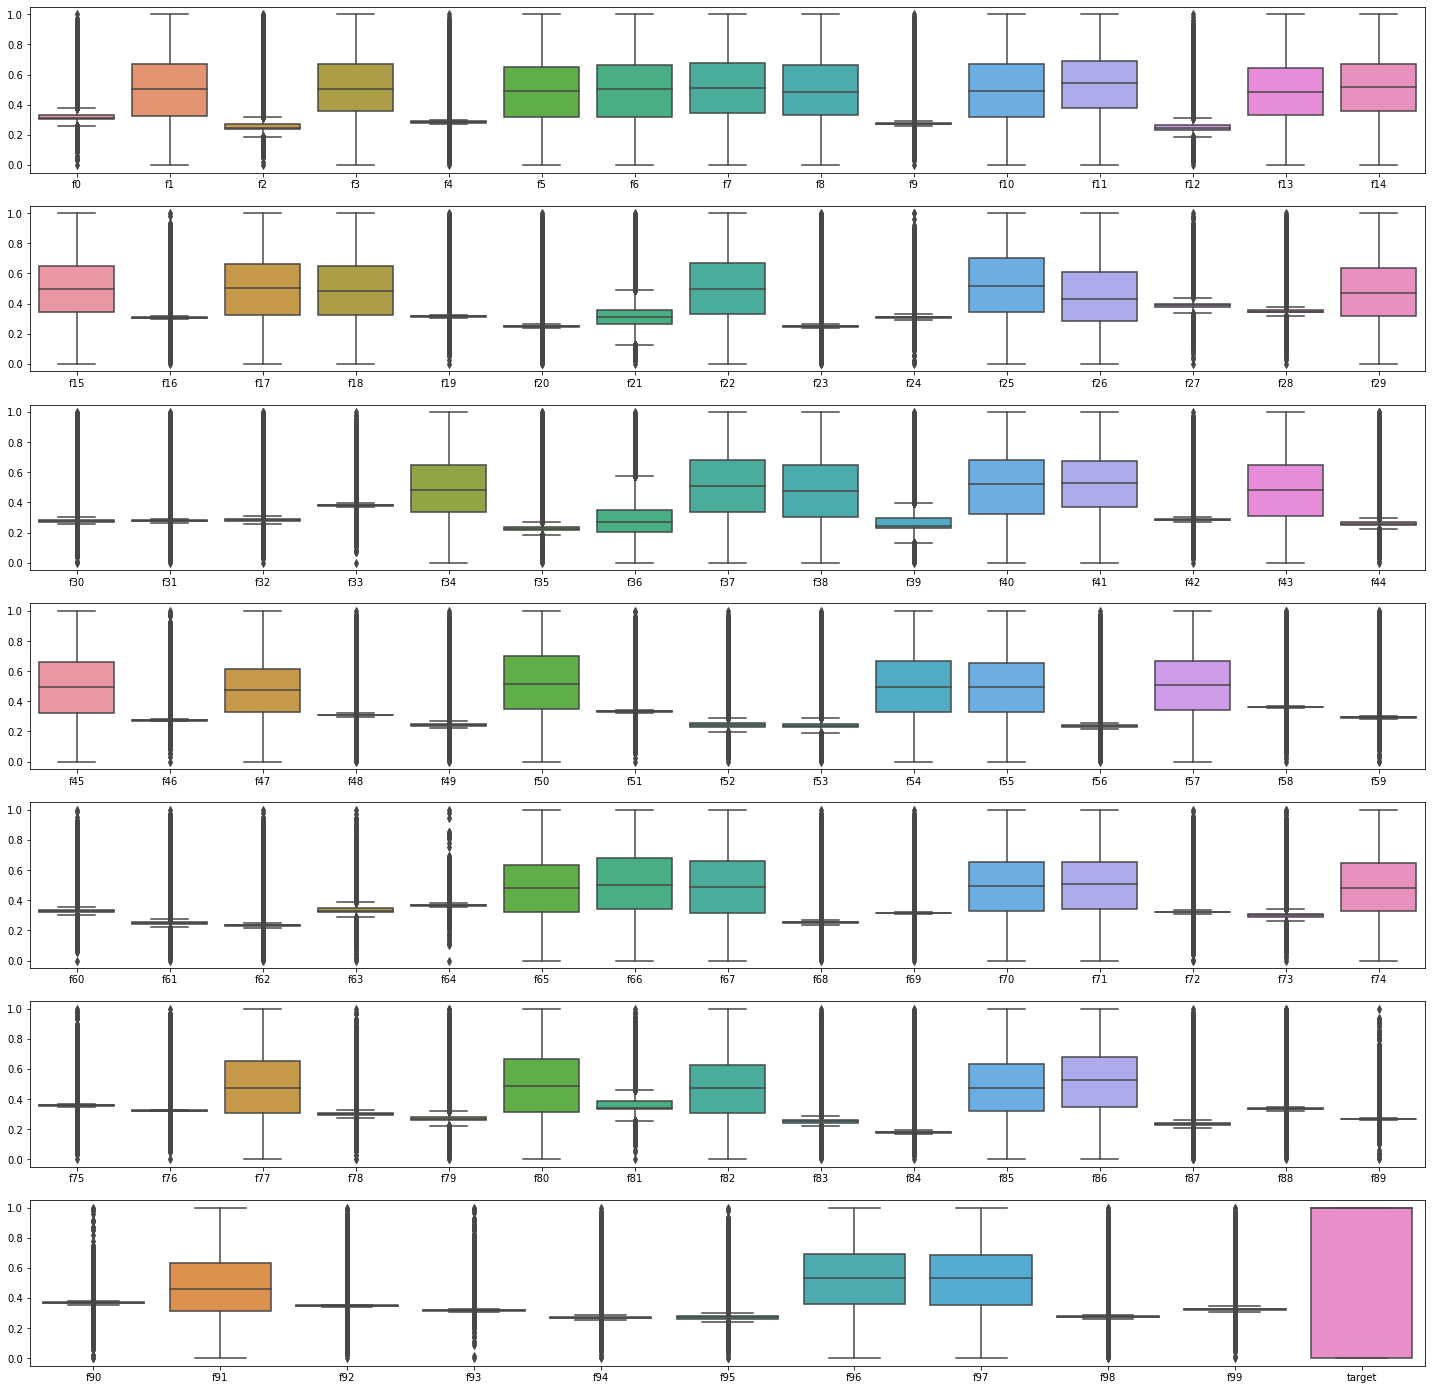

In [14]:
train_outliers = ((train - train.min())/(train.max() - train.min()))

fig, ax = plt.subplots(7, 1, figsize = (25,25))

sns.boxplot(data = train_outliers.iloc[:, 0:15], ax = ax[0])
sns.boxplot(data = train_outliers.iloc[:, 15:30], ax = ax[1])
sns.boxplot(data = train_outliers.iloc[:, 30:45], ax = ax[2])
sns.boxplot(data = train_outliers.iloc[:, 45:60], ax = ax[3])
sns.boxplot(data = train_outliers.iloc[:, 60:75], ax = ax[4])
sns.boxplot(data = train_outliers.iloc[:, 75:90], ax = ax[5])
sns.boxplot(data = train_outliers.iloc[:, 90:101], ax = ax[6])
plt.show()

del train_outliers

# Feature correlation

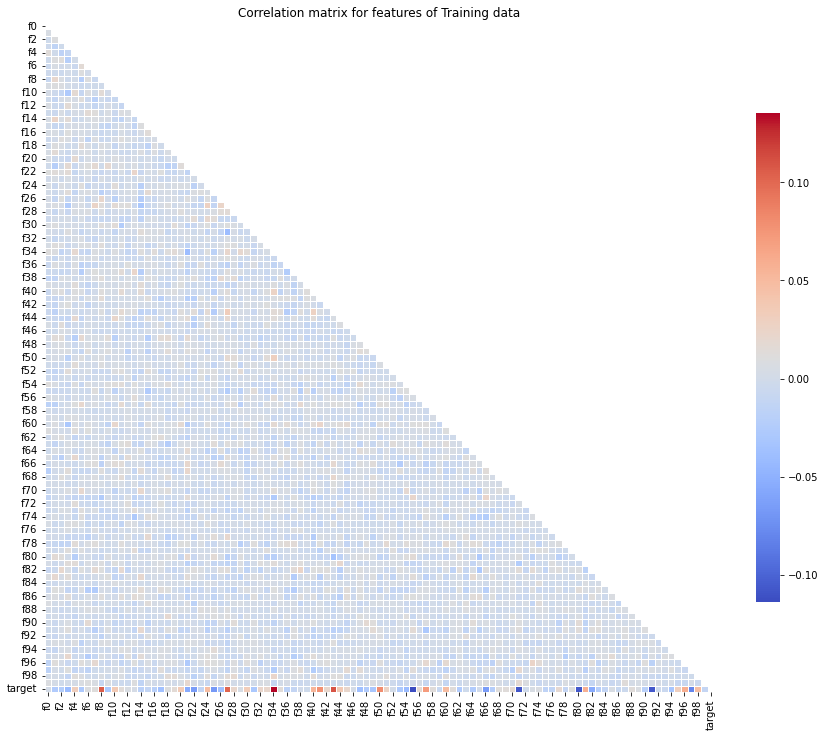

In [15]:
corr=train.corr()

mask = np.triu(np.ones_like(corr, dtype = bool))
plt.figure(figsize = (15, 15))
plt.title('Correlation matrix for features of Training data')
sns.heatmap(corr,cmap='coolwarm', mask = mask, annot=False, linewidths = .5,square=True, cbar_kws={"shrink": .60})
plt.show()

# Feature correlation with target

In [16]:
corr[['target']].sort_values(by='target', ascending=False).T.style.background_gradient(cmap="copper_r")

,target,f34,f43,f8,f27,f50,f41,f57,f96,f81,f40,f24,f60,f98,f44,f10,f20,f30,f4,f95,f51,f32,f45,f42,f33,f28,f77,f56,f70,f19,f11,f35,f69,f58,f88,f61,f7,f68,f79,f18,f6,f89,f74,f12,f85,f73,f29,f13,f46,f0,f52,f65,f38,f72,f63,f39,f92,f87,f93,f86,f59,f37,f99,f78,f15,f84,f23,f76,f75,f36,f14,f90,f16,f67,f83,f2,f62,f64,f1,f48,f53,f5,f9,f31,f49,f94,f17,f47,f26,f54,f3,f21,f82,f66,f22,f25,f97,f91,f80,f71,f55
target,1.000000,0.135270,0.109418,0.105724,0.101346,0.080300,0.078279,0.071250,0.059307,0.058122,0.054240,0.047963,0.047858,0.047160,0.037884,0.036279,0.035288,0.033946,0.031278,0.030190,0.027159,0.022683,0.022284,0.021936,0.021872,0.021458,0.018607,0.017678,0.017616,0.015800,0.014154,0.013717,0.013397,0.013125,0.012749,0.012739,0.012367,0.011769,0.009921,0.009538,0.008199,0.007431,0.007201,0.006501,0.005345,0.005068,0.004434,0.003760,0.002154,0.001653,0.000380,-0.000084,-0.000519,-0.001339,-0.002870,-0.002913,-0.004139,-0.004235,-0.006059,-0.008252,-0.008601,-0.011156,-0.011223,-0.011398,-0.012067,-0.012613,-0.013330,-0.014535,-0.015015,-0.017009,-0.017779,-0.019541,-0.019804,-0.022729,-0.023294,-0.023432,-0.025447,-0.025712,-0.025762,-0.026089,-0.028438,-0.029062,-0.029916,-0.030077,-0.031829,-0.032312,-0.036861,-0.037066,-0.037730,-0.041245,-0.041314,-0.055072,-0.055438,-0.064340,-0.064887,-0.067587,-0.080727,-0.106120,-0.106964,-0.107687,-0.113889


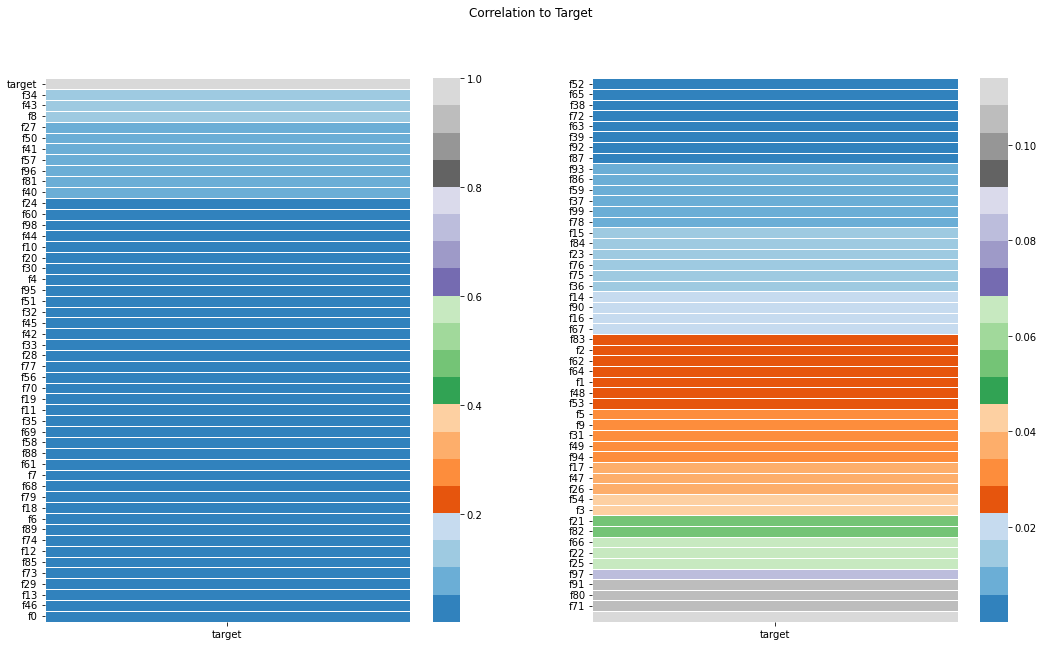

In [17]:
corr_ = abs(corr[['target']].sort_values(by='target', ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Correlation to Target')

sns.heatmap(ax=axes[0], data=corr_.iloc[0:50,:], annot=False, cmap='tab20c', linewidth=0.5, xticklabels=corr_.iloc[0:50,:].columns, yticklabels=corr_.iloc[0:50,:].index)
sns.heatmap(ax=axes[1], data=corr_.iloc[50:,:], annot=False, cmap='tab20c', linewidth=0.5, xticklabels=corr_.iloc[50:100,:].columns, yticklabels=corr_.iloc[50:100,:].index)
plt.show()

# Feature importance of LGBM

In [18]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

X = train[features]
y = train['target']

X_train, X_valid, y_train, y_valid = train_test_split(X, y,train_size=0.8,test_size = 0.2,random_state = 0)

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

importances_df = pd.DataFrame(lgbm.feature_importances_, columns=['Feature_Importance'],index=X_train.columns)
importances_df.sort_values(by=['Feature_Importance'], ascending=False, inplace=True)

In [19]:
importances_df.T.style.background_gradient(cmap="copper_r")

,f55,f91,f71,f8,f34,f80,f43,f27,f50,f97,f41,f22,f96,f66,f82,f57,f25,f81,f21,f26,f98,f24,f54,f20,f40,f47,f95,f17,f3,f5,f94,f9,f30,f10,f60,f53,f44,f49,f1,f51,f16,f48,f31,f32,f62,f45,f4,f64,f67,f2,f28,f93,f11,f83,f70,f36,f42,f15,f77,f58,f56,f90,f78,f23,f76,f68,f0,f33,f19,f61,f14,f86,f87,f88,f89,f29,f18,f92,f84,f13,f12,f7,f6,f85,f65,f63,f35,f37,f38,f79,f39,f46,f52,f75,f74,f73,f72,f59,f69,f99
Feature_Importance,161,149,143,142,128,126,122,121,108,102,96,89,88,86,83,82,76,76,68,56,52,51,46,44,39,39,38,37,35,34,34,33,30,29,29,28,28,28,24,18,16,15,14,13,12,12,10,10,9,9,9,8,8,7,7,6,6,5,5,5,3,2,2,2,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


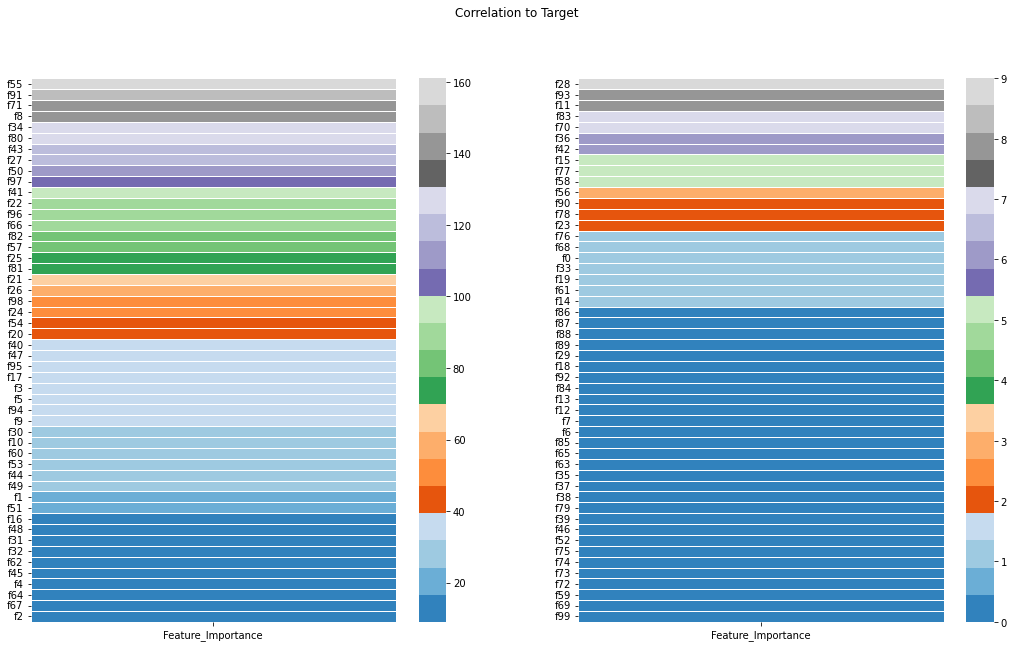

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Correlation to Target')

sns.heatmap(ax=axes[0], data=importances_df.iloc[0:50,:], annot=False,cmap='tab20c', linewidth=0.5, xticklabels=importances_df.iloc[0:50,:].columns, yticklabels=importances_df.iloc[0:50,:].index)
sns.heatmap(ax=axes[1], data=importances_df.iloc[50:,:], annot=False,cmap='tab20c', linewidth=0.5, xticklabels=importances_df.iloc[50:100,:].columns, yticklabels=importances_df.iloc[50:100,:].index)
plt.show()

# Baseline lgbm submission

In [21]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_valid, lgbm.predict_proba(X_valid)[:, 1]))

0.7337019389860318


In [22]:
test_preds = lgbm.predict_proba(test)[:, 1]
sample_submission['target'] = test_preds
sample_submission.to_csv('submission.csv', index=False)

# Observation
#### * The test dataset is approx equal to the size of the training dataset
#### * The training dataset is highly representative of the test dataset
#### * There is no missing data
#### * There is no binary features
#### * There is relatively low correlation between features
#### * There appears to be a relatively high correlation between f34 and target value.
#### * Feature have show both positive and negative correlations to target classification.
#### * Feature importance doesn't indicate f34 as an important feature.
#### * Feature importance indicates f91 as important feature

# Next notebook
##### What's in it?
* Training many different models and see which model is performing well.
* Feature importances of each model.

#### Link: https://www.kaggle.com/rigeltal/tps-11-starter

# Final note
#### Thank you!
##### If you like it please upvote it. If you have suggestion please leave it in comment. Even I am beginner looking forward to learn something new. So let me know how can I improve this